In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, auc,
    roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)
import joblib

# SMOTE needs imbalanced-learn, xgboost is optional - both handled so the notebook
# still runs even if one of them isn't installed
try:
    from imblearn.over_sampling import SMOTE
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn not installed - run: pip install imbalanced-learn")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - using GradientBoostingClassifier instead")

imbalanced-learn not installed - run: pip install imbalanced-learn


In [2]:
# Load the dataset
print("Loading data...")
try:
    df = pd.read_csv('Fraud.csv', low_memory=False)
except FileNotFoundError:
    raise FileNotFoundError("Fraud.csv not found. Keep it in the same folder as this notebook.")
print(f"Data loaded successfully. Shape: {df.shape}")

Loading data...
Data loaded successfully. Shape: (6362620, 11)


In [3]:
# downcast numeric columns so the big file doesn't eat all the RAM
# when we train several models later on
for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    df[col] = pd.to_numeric(df[col], downcast='float')
df['step'] = pd.to_numeric(df['step'], downcast='integer')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int16  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int16(1), int64(2), object(3)
memory usage: 497.6+ MB


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df.dtypes

step                int16
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [7]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


### Target variable

In [8]:
# how many no of frauds
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
# calculate fraud percentage
fraud_percentage = (df['isFraud'].sum() / len(df)) * 100
fraud_percentage

np.float64(0.12908204481801522)

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

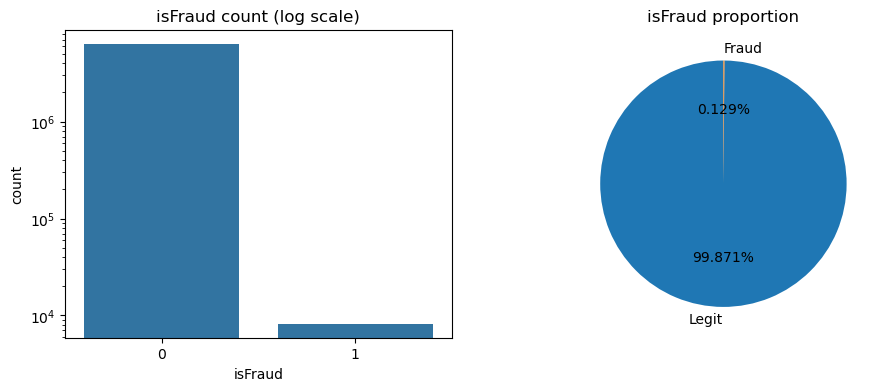

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='isFraud', data=df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('isFraud count (log scale)')

axes[1].pie(df['isFraud'].value_counts(), labels=['Legit', 'Fraud'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('isFraud proportion')
plt.show()

### Transaction type

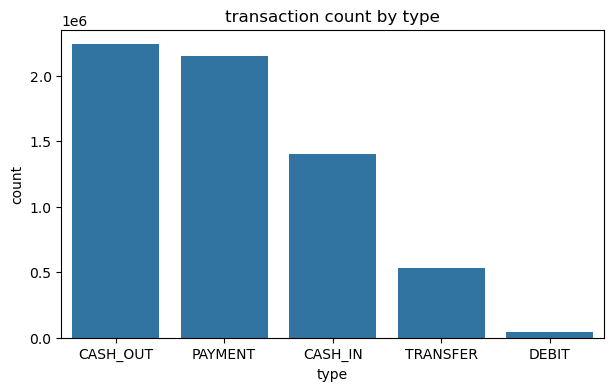

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('transaction count by type')
plt.show()

           sum    count  fraud_rate_%
type                                 
CASH_IN      0  1399284      0.000000
CASH_OUT  4116  2237500      0.183955
DEBIT        0    41432      0.000000
PAYMENT      0  2151495      0.000000
TRANSFER  4097   532909      0.768799


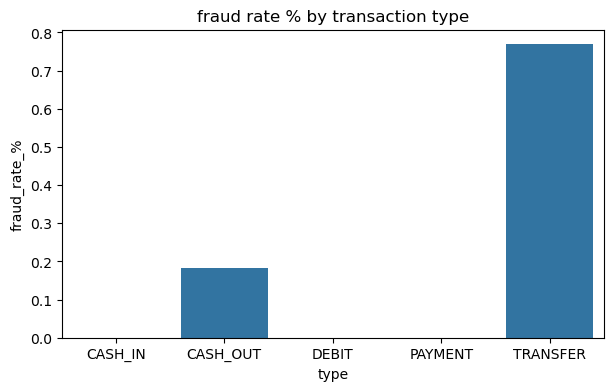

In [13]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type['fraud_rate_%'] = fraud_by_type['sum'] / fraud_by_type['count'] * 100
print(fraud_by_type)

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type['fraud_rate_%'])
plt.title('fraud rate % by transaction type')
plt.show()

### Amount analysis

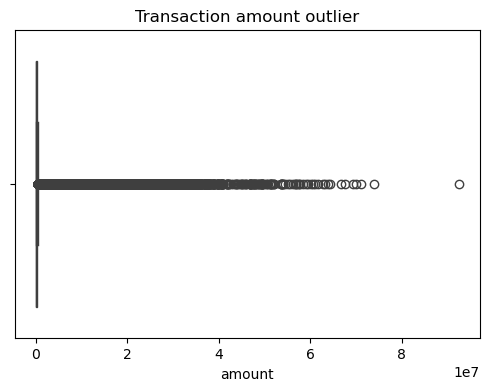

In [14]:
# outlier detection
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['amount'])
plt.title('Transaction amount outlier')
plt.show()

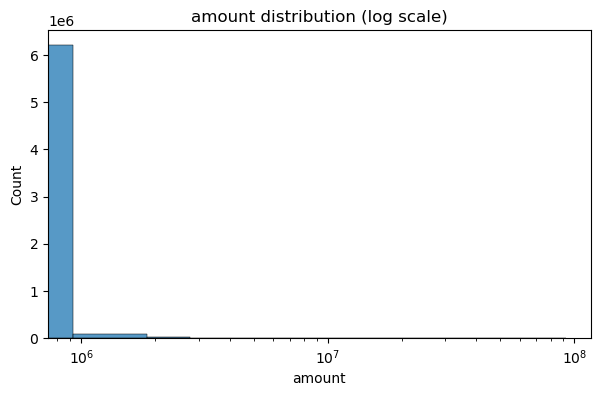

In [15]:
plt.figure(figsize=(7, 4))
sns.histplot(df['amount'], bins=100)
plt.xscale('log')
plt.title('amount distribution (log scale)')
plt.show()

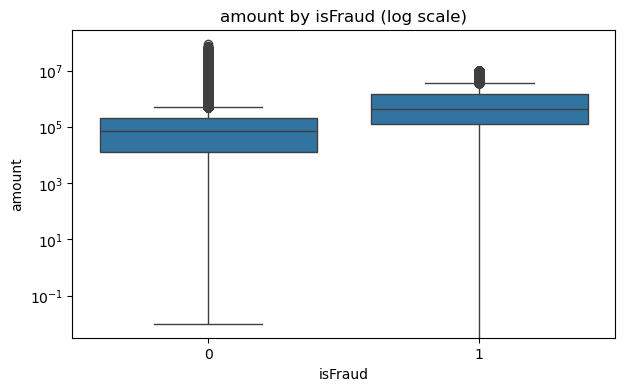

In [16]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title('amount by isFraud (log scale)')
plt.show()

### Fraud over time (step)

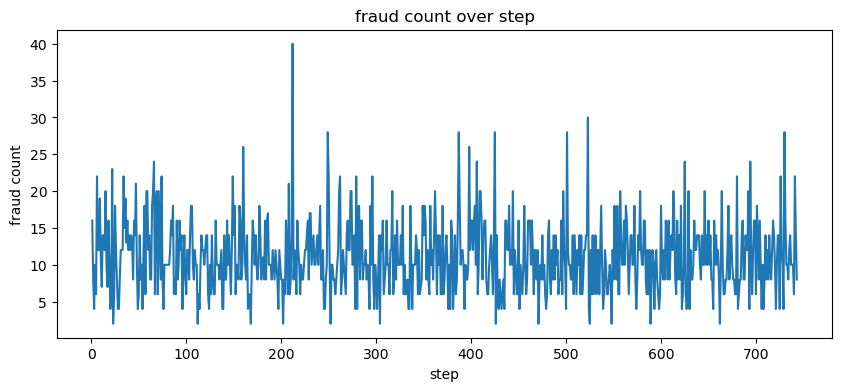

In [17]:
fraud_by_step = df[df['isFraud'] == 1].groupby('step').size()
plt.figure(figsize=(10, 4))
plt.plot(fraud_by_step.index, fraud_by_step.values)
plt.title('fraud count over step')
plt.xlabel('step')
plt.ylabel('fraud count')
plt.show()

### Balance based feature check

In [18]:


df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

In [19]:
df[['balance_diff_orig', 'balance_diff_dest']].describe()

,balance_diff_orig,balance_diff_dest
count,6.362620e+06,6.362620e+06
mean,-2.010925e+05,-5.556717e+04
std,6.066505e+05,4.415288e+05
min,-9.244552e+07,-1.319123e+07
25%,-2.496411e+05,-2.935305e+04
50%,-6.867726e+04,-3.500490e+03
75%,-2.954230e+03,0.000000e+00
max,1.000000e-02,7.588573e+07


In [20]:
# understanding feature types and separate columns types
numerical_cols = [
    'step', 'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]
categorical_cols = ['type']
identifier_cols = ['nameOrig', 'nameDest']
target_col = 'isFraud'

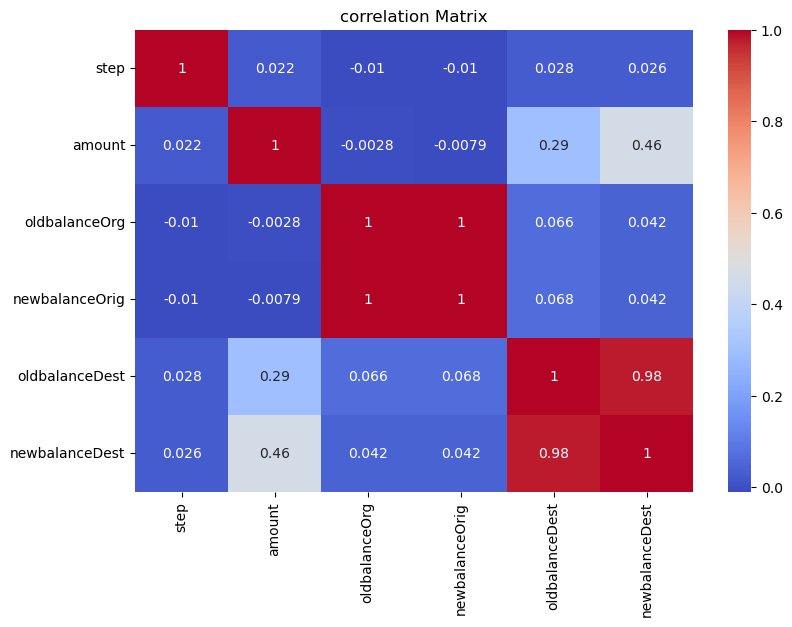

In [21]:
# Multicollinearity - correlation Matrix
plt.figure(figsize=(9, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("correlation Matrix")
plt.show()

### Feature engineering

In [22]:
print("Engineering features...")

# 1. Calculate the mathematical errors in the balances
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 2. Drop irrelevant columns
# nameOrig/nameDest are just identifiers, isFlaggedFraud is a static rule from the dataset
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# 3. One-Hot Encode the 'type' column (CASH_OUT, TRANSFER, etc.)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

print(f"Feature engineering complete. New shape: {df.shape}")

Engineering features...
Feature engineering complete. New shape: (6362620, 15)


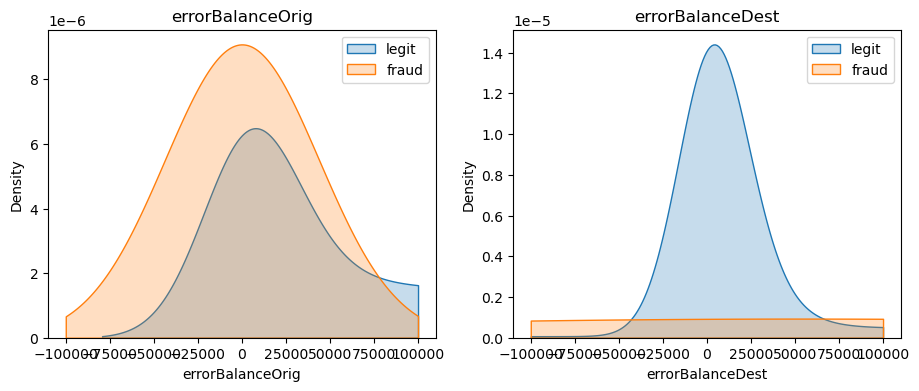

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ['errorBalanceOrig', 'errorBalanceDest']):
    sns.kdeplot(df.loc[df['isFraud'] == 0, col], ax=ax, label='legit', fill=True, clip=(-1e5, 1e5))
    sns.kdeplot(df.loc[df['isFraud'] == 1, col], ax=ax, label='fraud', fill=True, clip=(-1e5, 1e5))
    ax.set_title(col)
    ax.legend()
plt.show()

### Train-test split (full data)

In [24]:
print("Splitting data...")
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Data split complete.")

Splitting data...
Data split complete.


### Final model - HistGradientBoosting on full data

In [25]:
print("Training HistGradientBoostingClassifier...")

# We do NOT use class_weight='balanced' to protect our precision!
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=12,
    learning_rate=0.1,
    random_state=42
)

hgb_model.fit(X_train, y_train)
print("Model training complete.")

Training HistGradientBoostingClassifier...


  File "C:\Users\kk446\anaconda1\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\kk446\anaconda1\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kk446\anaconda1\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kk446\anaconda1\Lib\subprocess.

Model training complete.


Evaluating model...

--- Confusion Matrix ---
[[1906295      27]
 [      9    2455]]
True Negatives: 1906295
False Positives: 27
False Negatives: 9
True Positives: 2455


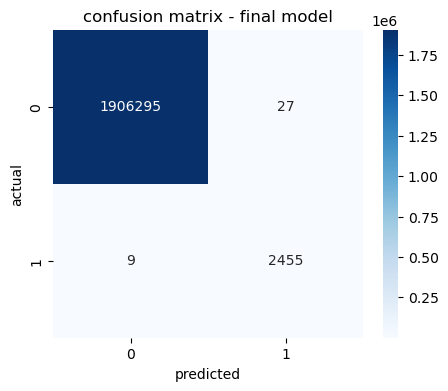

In [26]:
print("Evaluating model...")
y_pred = hgb_model.predict(X_test)
y_pred_proba = hgb_model.predict_proba(X_test)[:, 1]

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('confusion matrix - final model')
plt.ylabel('actual')
plt.xlabel('predicted')
plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.99      1.00      0.99      2464

    accuracy                           1.00   1908786
   macro avg       0.99      1.00      1.00   1908786
weighted avg       1.00      1.00      1.00   1908786


--- PR-AUC Score: 0.9952 ---


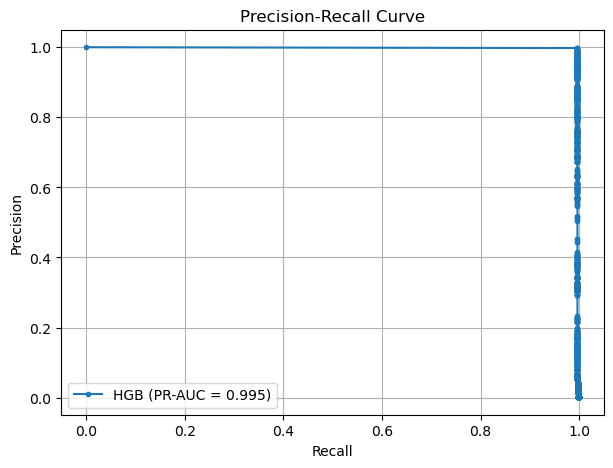

In [27]:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"\n--- PR-AUC Score: {pr_auc:.4f} ---")

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, marker='.', label=f'HGB (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

ROC AUC Score: 0.9976686191410721


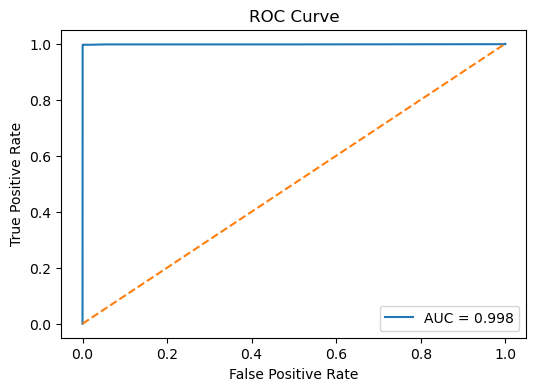

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", auc_score)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [29]:
print("Saving model...")
os.makedirs("models", exist_ok=True)
joblib.dump(hgb_model, "models/fraud_hgb_model.pkl")
print("Model saved successfully in the 'models' folder!")

Saving model...
Model saved successfully in the 'models' folder!


### Comparing multiple algorithms

In [30]:
# training + comparing multiple algos on the full 6.3M rows (with SMOTE later) is too slow,
# so this part uses a big stratified sample - all fraud rows + a chunk of legit rows
SAMPLE_NONFRAUD_SIZE = 150000

fraud_idx = y[y == 1].index
nonfraud_idx = y[y == 0].sample(n=min(SAMPLE_NONFRAUD_SIZE, (y == 0).sum()), random_state=42).index
sample_idx = fraud_idx.union(nonfraud_idx)

X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]
print(f"sample size: {X_sample.shape[0]}, fraud rate: {y_sample.mean()*100:.2f}%")

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample
)

sample size: 158213, fraud rate: 5.19%


In [31]:
XGB_LABEL = "XGBoost" if HAS_XGB else "Gradient Boosting"

def build_models():
    # fresh unfitted models every time this is called
    if HAS_XGB:
        xgb_or_gbm = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                    eval_metric='logloss', random_state=42, n_jobs=-1)
    else:
        xgb_or_gbm = GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)

    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
        XGB_LABEL: xgb_or_gbm,
        "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, max_depth=12, learning_rate=0.1, random_state=42),
    }

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, resampling_tag):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    p_curve, r_curve, _ = precision_recall_curve(y_te, y_proba)

    return {
        "Model": name,
        "Resampling": resampling_tag,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "PR-AUC": auc(r_curve, p_curve),
        "_y_proba": y_proba,
    }

In [32]:
print("training baseline models (no resampling)...")
baseline_results = []
for name, model in build_models().items():
    print(" -", name)
    baseline_results.append(evaluate_model(name, model, X_train_s, y_train_s, X_test_s, y_test_s, "No SMOTE"))
print("done")

training baseline models (no resampling)...
 - Logistic Regression
 - Random Forest
 - XGBoost
 - HistGradientBoosting
done


### SMOTE - does it actually help?

In [33]:
# SMOTE only on the training data, never on the test set, else it's data leakage
smote_results = []

if HAS_IMBLEARN:
    print("before SMOTE:")
    print(y_train_s.value_counts())

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train_s)

    print("\nafter SMOTE:")
    print(pd.Series(y_train_smote).value_counts())
else:
    print("imbalanced-learn not installed, skipping SMOTE part")

imbalanced-learn not installed, skipping SMOTE part


In [34]:
if HAS_IMBLEARN:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.countplot(x=y_train_s, ax=axes[0])
    axes[0].set_title('before SMOTE')
    sns.countplot(x=y_train_smote, ax=axes[1])
    axes[1].set_title('after SMOTE')
    plt.show()

In [35]:
if HAS_IMBLEARN:
    print("training the same models again on the SMOTE resampled data...")
    for name, model in build_models().items():
        print(" -", name)
        smote_results.append(evaluate_model(name, model, X_train_smote, y_train_smote, X_test_s, y_test_s, "SMOTE"))
    print("done")

### Result comparison

In [36]:
all_results = baseline_results + smote_results
summary_df = pd.DataFrame(all_results).drop(columns=['_y_proba'])
summary_df = summary_df.sort_values(['Model', 'Resampling']).reset_index(drop=True)
summary_df.round(4)

,Model,Resampling,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,HistGradientBoosting,No SMOTE,0.9998,0.9996,0.9963,0.9980,0.9994,0.9990
1,Logistic Regression,No SMOTE,0.9830,0.9290,0.7273,0.8158,0.9858,0.9082
2,Random Forest,No SMOTE,0.9998,1.0000,0.9959,0.9980,0.9996,0.9988
3,XGBoost,No SMOTE,0.9995,0.9951,0.9951,0.9951,0.9997,0.9987


In [37]:
summary_df.sort_values('PR-AUC', ascending=False)[['Model', 'Resampling', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']]

,Model,Resampling,Precision,Recall,F1,ROC-AUC,PR-AUC
0,HistGradientBoosting,No SMOTE,0.999593,0.996347,0.997967,0.999358,0.999044
2,Random Forest,No SMOTE,1.000000,0.995942,0.997967,0.999635,0.998800
3,XGBoost,No SMOTE,0.995130,0.995130,0.995130,0.999738,0.998723
1,Logistic Regression,No SMOTE,0.928979,0.727273,0.815843,0.985847,0.908151


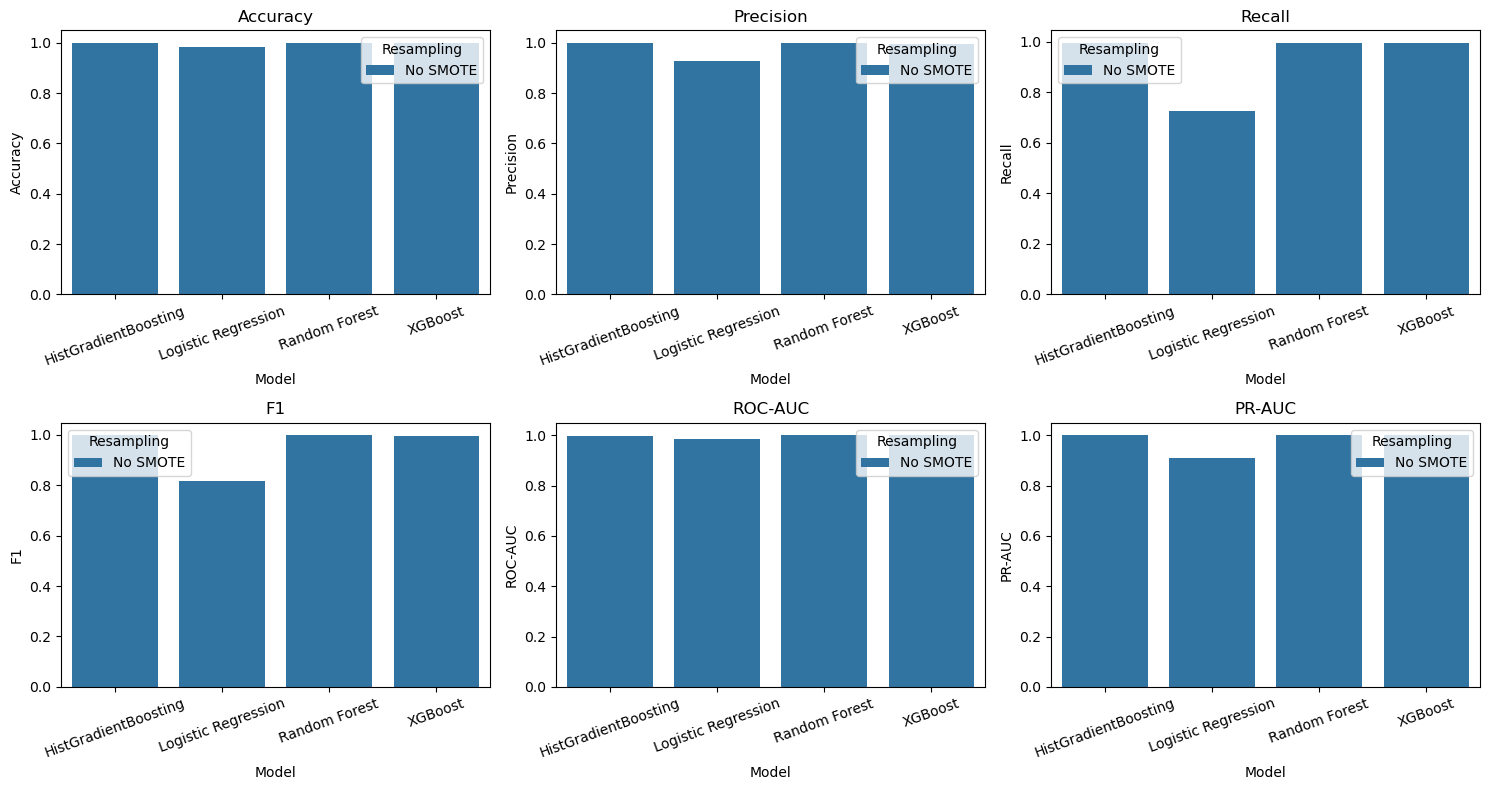

In [38]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=summary_df, x='Model', y=metric, hue='Resampling', ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

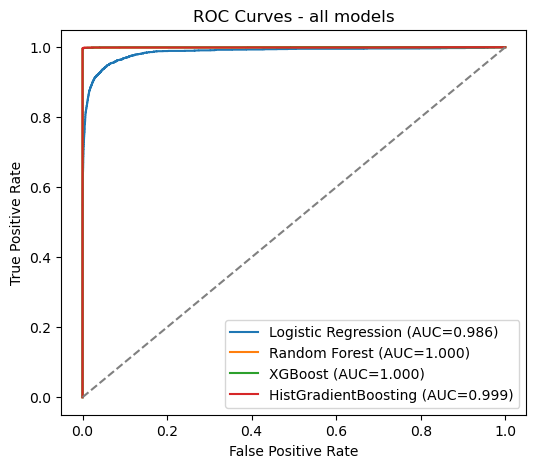

In [39]:
plt.figure(figsize=(6, 5))
curves_source = smote_results if smote_results else baseline_results
for result in curves_source:
    fpr, tpr, _ = roc_curve(y_test_s, result['_y_proba'])
    plt.plot(fpr, tpr, label=f"{result['Model']} (AUC={result['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - all models')
plt.legend()
plt.show()

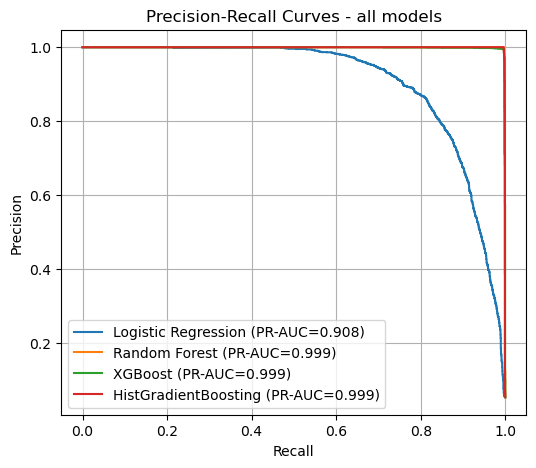

In [40]:
plt.figure(figsize=(6, 5))
for result in curves_source:
    p, r, _ = precision_recall_curve(y_test_s, result['_y_proba'])
    plt.plot(r, p, label=f"{result['Model']} (PR-AUC={result['PR-AUC']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - all models')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
best_row = max(curves_source, key=lambda r: r['PR-AUC'])
print("best model by PR-AUC:", best_row['Model'])

best_model = build_models()[best_row['Model']]
train_X = X_train_smote if smote_results else X_train_s
train_y = y_train_smote if smote_results else y_train_s
best_model.fit(train_X, train_y)

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=train_X.columns)
    importances = importances.sort_values(ascending=False).head(10)
    plt.figure(figsize=(7, 5))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'top 10 feature importances - {best_row["Model"]}')
    plt.show()

best model by PR-AUC: HistGradientBoosting
